<a href="https://colab.research.google.com/github/kaifkh20/d2l/blob/main/house_prices_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install d2l --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 2.2 MB/s eta 0:00:00


In [ ]:
%matplotlib inline
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader,Subset,Dataset,TensorDataset
import numpy as np

In [ ]:
class KaggleHouse(d2l.DataModule):
    def __init__(self, batch_size, train=None, val=None):
        super().__init__()
        self.save_hyperparameters()
        if self.train is None:
            self.raw_train = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_train.csv', self.root,
                sha1_hash='585e9cc93e70b39160e7921475f9bcd7d31219ce'))
            self.raw_val = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_test.csv', self.root,
                sha1_hash='fa19780a7b011d9b009e8bff8e99922a8ee2eb90'))


In [ ]:
data = KaggleHouse(batch_size=64)
print(data.raw_train.shape)
print(data.raw_val.shape)


(1460, 81)
(1459, 80)


In [ ]:
#select first 4rows and first 4 columns and last 3 columns
print(data.raw_train.iloc[:4, [0, 1, 2, 3, -3, -2, -1]])


   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [ ]:
@d2l.add_to_class(KaggleHouse)
def preprocess(self):
    # Remove the ID and label columns
    label = 'SalePrice'
    features = pd.concat(
        (self.raw_train.drop(columns=['Id', label]),
         self.raw_val.drop(columns=['Id'])))
    # Standardize numerical columns
    numeric_features = features.dtypes[features.dtypes!='object'].index
    features[numeric_features] = features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std()))
    # Replace NAN numerical features by 0
    features[numeric_features] = features[numeric_features].fillna(0)
    # Replace discrete features by one-hot encoding
    features = pd.get_dummies(features, dummy_na=True)
    # Save preprocessed features
    self.train = features[:self.raw_train.shape[0]].copy()
    self.train[label] = self.raw_train[label]
    self.val = features[self.raw_train.shape[0]:].copy()



In [ ]:
#the features increase from 79 to 331 because we do hot encoding
data.preprocess()
data.train.shape


(1460, 331)

We use LRMES instead of RMES beacuse we now need Relative Error and not Absolute Error

like -> In house prediction if a model predicts 200 for 100 that is a big error but if the same model predicts 12200 for 12000 that is actually close so absolute error will treat this as same but

in LRMES will treat this as different penalizing one more than the other one


In [ ]:
@d2l.add_to_class(KaggleHouse)
def get_dataloader(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data: return
    get_tensor = lambda x: torch.tensor(x.values.astype(float),
                                      dtype=torch.float32)
    # Logarithm of prices
    # we get Y as log because we want to calculate root(log(y)-log(y^)) #for relative error
    tensors = (get_tensor(data.drop(columns=[label])),  # X
               torch.log(get_tensor(data[label])).reshape((-1, 1)))  # Y
    return self.get_tensorloader(tensors, train)


In [ ]:
#gets one idx validation data set and rest training data set

def k_fold_data(data, k):
    rets = []
    fold_size = data.train.shape[0] // k
    for j in range(k):
        idx = range(j * fold_size, (j+1) * fold_size)
        rets.append(KaggleHouse(data.batch_size, data.train.drop(index=idx),
                                data.train.loc[idx]))
    return rets

def k_fold(trainer, data, k, lr):
    val_loss, models = [], []
    for i, data_fold in enumerate(k_fold_data(data, k)):
        model = d2l.LinearRegression(lr)
        model.board.yscale='log'
        if i != 0: model.board.display = False
        trainer.fit(model, data_fold)
        val_loss.append(float(model.board.data['val_loss'][-1].y))
        models.append(model)
    print(f'average validation log mse = {sum(val_loss)/len(val_loss)}')
    return models


average validation log mse = 0.18084125220775604


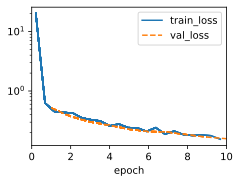

In [ ]:
trainer = d2l.Trainer(max_epochs=10)
models = k_fold(trainer, data, k=5, lr=0.01)



Since we pass the validation set through each model each model predicts different for each and every house we get k preds

to reduce variance and get a smoother and more accurate value we average it.

In [ ]:
#we pass the validation test through each trained model

preds = [model(torch.tensor(data.val.values.astype(float), dtype=torch.float32))
         for model in models]
# Taking exponentiation of predictions in the logarithm scale because we predicted in logscale
ensemble_preds = torch.exp(torch.cat(preds, 1)).mean(1)
submission = pd.DataFrame({'Id':data.raw_val.Id,
                           'SalePrice':ensemble_preds.detach().numpy()})
submission.to_csv('submission.csv', index=False)

print(submission.head())

     Id      SalePrice
0  1461   90804.640625
1  1462  584163.375000
2  1463  190127.781250
3  1464  248348.671875
4  1465  182946.640625


In a pure pytorchic with deep neural nets and kaggle dataset using d2l


In [ ]:
@d2l.add_to_class(KaggleHouse)
def get_dataset(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data:
        return None
    get_tensor = lambda x: torch.tensor(x.values.astype(float),
                                      dtype=torch.float32)
    # Logarithm of prices
    tensors = (get_tensor(data.drop(columns=[label])),  # X
               torch.log(get_tensor(data[label])).reshape((-1, 1)))  # Y
    return TensorDataset(*tensors)  # Return dataset, not dataloader


In [ ]:
# Initialize and preprocess data
data = KaggleHouse(batch_size=64)
data.preprocess()

dataset = data.get_dataset(train=True)

In [ ]:
class HousePredict(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.LazyLinear(256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.LazyLinear(64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.LazyLinear(1)
     )

  def forward(self,X):
    return self.net(X)

In [ ]:
# K-Fold Setup
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
all_val_losses = []
trained_models = []

In [ ]:
for fold, (train_indices, val_indices) in enumerate(kf.split(dataset)):
    print(f"--- Fold {fold+1}/{k_folds} ---")
    train_subset = Subset(dataset, train_indices)
    val_subset = Subset(dataset, val_indices)
    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

    model = HousePredict()
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(100):
        model.train()
        epoch_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            y_hat = model(inputs)  # Pass inputs to model
            loss = loss_fn(y_hat, labels)  # Compare predictions with labels
            loss.backward()
            optimizer.step()
            epoch_loss = loss.item()
        # Optional: Print training progress
        if (epoch + 1) % 10 == 0:
            avg_epoch_loss = epoch_loss / len(train_loader)
            print(f"    Epoch {epoch+1}/100, Training Loss: {avg_epoch_loss:.4f}")

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = torch.sqrt(loss_fn(outputs, labels))  # Use loss_fn, not criterion
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    all_val_losses.append(avg_val_loss)
    print(f"  Validation RMSE: {avg_val_loss:.4f}")

    trained_models.append(model)
    print(f"\n=== Cross-Validation Results ===")

print(f"Average RMSE: {np.mean(all_val_losses):.4f}")
print(f"Std RMSE: {np.std(all_val_losses):.4f}")
print(f"All fold RMSEs: {[f'{loss:.4f}' for loss in all_val_losses]}")


--- Fold 1/5 ---
    Epoch 10/100, Training Loss: 0.1383
    Epoch 20/100, Training Loss: 0.1856
    Epoch 30/100, Training Loss: 0.0881
    Epoch 40/100, Training Loss: 0.1752
    Epoch 50/100, Training Loss: 0.0992
    Epoch 60/100, Training Loss: 0.0612
    Epoch 70/100, Training Loss: 0.0717
    Epoch 80/100, Training Loss: 0.1427
    Epoch 90/100, Training Loss: 0.0879
    Epoch 100/100, Training Loss: 0.1644
  Validation RMSE: 0.2876

=== Cross-Validation Results ===
--- Fold 2/5 ---
    Epoch 10/100, Training Loss: 0.1456
    Epoch 20/100, Training Loss: 0.1295
    Epoch 30/100, Training Loss: 0.0930
    Epoch 40/100, Training Loss: 0.1581
    Epoch 50/100, Training Loss: 0.1473
    Epoch 60/100, Training Loss: 0.0857
    Epoch 70/100, Training Loss: 0.0913
    Epoch 80/100, Training Loss: 0.0963
    Epoch 90/100, Training Loss: 0.0950
    Epoch 100/100, Training Loss: 0.0783
  Validation RMSE: 0.2342

=== Cross-Validation Results ===
--- Fold 3/5 ---
    Epoch 10/100, Training 

In [ ]:
# We pass the validation test through each trained model
# Note: data.val only contains features (no SalePrice column for test set)
test_features = torch.tensor(data.val.values.astype(float), dtype=torch.float32)

preds = []
for model in trained_models:  # Use trained_models from your k-fold loop
    model.eval()
    with torch.no_grad():
        pred = model(test_features)
        preds.append(pred)

# Since you trained in log scale, take exp to get back to original scale
ensemble_preds = torch.exp(torch.cat(preds, 1)).mean(1)

submission = pd.DataFrame({
    'Id': data.raw_val.Id,
    'SalePrice': ensemble_preds.detach().numpy()
})
submission.to_csv('submission(1).csv', index=False)

print(f"Submission saved with {len(trained_models)} model predictions")
print(f"Submission shape: {submission.shape}")
print(submission.head())

Submission saved with 20 model predictions
Submission shape: (1459, 2)
     Id      SalePrice
0  1461  112014.375000
1  1462  287608.375000
2  1463  157476.453125
3  1464  188274.343750
4  1465  182609.328125
